# R09 communities - H68 provenance NMI, H69 diversified seeding, H70 conductance merge gate

**Author**: Knowledge Graph Foundry autonomous build (kj) <br>
**Date**: 2026-07-07 <br>
**Pipeline stage**: R09 graph topology round, community family <br>
**Graph**: rebuilt CPAP graph (neo4j2, READ-ONLY), 28-probe gold set (24 with gold, 33 golds) <br>

Three community-structure hypotheses on the same fresh Leiden partition.

- **H68** - is community structure just document provenance? NMI(Leiden community, dominant source document); bar NMI >= 0.6 confirms provenance artifact, NMI < 0.3 refutes (communities genuinely cross-document)
- **H69** - can community-diversified seeding beat pure vector@16? bar diversified@16 >= 0.90 vs the 0.854 vector bar; probes whose 16 seeds span <=2 communities should recall less
- **H70** - are false merges disproportionately cross-community? bar false cross-community rate >= 2x true-merge rate; the conductance/community-mismatch veto should drop false closures without regressing legitimate multi-doc identity

All GDS runs are STREAM mode (no property writes). Graph mutations for injection live on in-memory copies only.

## Outputs
- `reports/communities-r09-<stamp>.json` - NMI, seeding recall table, merge-gate rates, verdicts

In [1]:
# Imports
# stdlib
import datetime  # report stamps
import json  # report persistence
import os  # graph selection env
import re  # evidence normalization
from collections import Counter, deque  # ranking, BFS

# third party
import numpy as np  # numeric
import yaml  # probe set
import matplotlib.pyplot as plt  # figures
from pathlib import Path
from sklearn.metrics import normalized_mutual_info_score, homogeneity_score  # H68
from rich import print as rprint  # semantic output
from rich.progress import Progress  # loops

os.environ["NEO4J_URI"] = "bolt://user-konrad.jelen-kgf-neo4j2:7687"
os.environ["NEO4J_USER"] = "neo4j"
os.environ["NEO4J_PASSWORD"] = "kgfoundry"

# project
from knowledge_graph_foundry import Foundry, load_settings  # pipeline
from knowledge_graph_foundry.extraction import generate_embeddings  # Titan probe embedding
from knowledge_graph_foundry.graph.graphrag import vector_query  # seed channel
from knowledge_graph_foundry.graph.propositions import proposition_query  # seed channel
from knowledge_graph_foundry.models import Entity  # embedding probe wrapper

2026-07-07 11:05:29.687 | INFO     | knowledge_graph_foundry.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/knowledge-graph-foundry


In [2]:
# Configuration
PROBES_PATH = Path("../tests/probes/cpap-probe-set.yml")
settings = load_settings(Path("../config.yml"))
TOP_K = settings.graphrag.top_k                  # production vector seeds (8)
TOP_K_WIDE = 16                                  # H53 budget bar
PROP_TOP_K = settings.graphrag.proposition_top_k
VEC_INDEX = settings.graphrag.vector_index_name
PROP_INDEX = settings.graphrag.proposition_index_name
REL_LIMIT = 15                                   # production per-node relation cap

# pre-registered bars
BAR_H68_HIGH = 0.60     # NMI >= 0.6 -> provenance artifact
BAR_H68_LOW = 0.30      # NMI < 0.3 -> genuinely cross-document
BAR_H69_DIVERSE = 0.90  # diversified@16 target
BAR_H69_VECTOR = 0.854  # standing vector@16 bar
BAR_H70_RATIO = 2.0     # false cross-community rate >= 2x true

probes = yaml.safe_load(PROBES_PATH.read_text())
gold_probes = [p for p in probes if p.get("gold_evidence")]
n_golds = sum(len(p["gold_evidence"]) for p in gold_probes)

rprint(f"""[bold cyan]Configuration[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
[bold]Graph[/bold] neo4j2 (read-only)  probes [yellow]{len(gold_probes)}[/yellow]  golds [yellow]{n_golds}[/yellow]
[bold]Seeding[/bold] vector top-k [yellow]{TOP_K}[/yellow] wide [yellow]{TOP_K_WIDE}[/yellow]  prop top-k [yellow]{PROP_TOP_K}[/yellow]  rel cap [yellow]{REL_LIMIT}[/yellow]
[bold]Bars[/bold] H68 NMI >= [yellow]{BAR_H68_HIGH}[/yellow] (refute < {BAR_H68_LOW})  H69 diversified >= [yellow]{BAR_H69_DIVERSE}[/yellow] (vector {BAR_H69_VECTOR})  H70 ratio >= [yellow]{BAR_H70_RATIO}[/yellow]x
""")

Configuration
────────────────────────────────────────
Graph neo4j2 (read-only)  probes 24  golds 33
Seeding vector top-k 8 wide 16  prop top-k 8  rel cap 15
Bars H68 NMI >= 0.6 (refute < 0.3)  H69 diversified >= 0.9 (vector 0.854)  H70 ratio >= 2.0x

## Graph snapshot, fresh Leiden partition, render surfaces

One load pass: entities (id, name, description, props, source_documents), currently-valid
non-SIMILAR_TO edges, SAME_AS pairs, attached proposition texts. Fresh Leiden runs in GDS
STREAM mode over an undirected projection of the valid non-SIMILAR_TO edges. Render surface
per entity = name + description + spec + SAME_AS alias names + capped relation lines, matching
the production vector-channel render.

In [3]:
# H67 present() matcher - copied verbatim
def _norm(s):
    return re.sub(r"\s+", " ", s.casefold())


def value_tokens(text):
    return re.findall(r"[\w.\-/]*\d[\w.\-/]*", text)


_UNIT = r"(?<=\d)\s*(mm|cm|dba|db\(a\)|db|kg|g|oz|ml|l|w|hz|mins|min|m)\b"


def present(gold, ctx_norm):
    ng = _norm(gold)
    if ng in ctx_norm:
        return True
    squashed = re.sub(r"[\s,()]", "", ctx_norm)
    skeleton = re.sub(r"[\s,()]", "", re.sub(_UNIT, "", ng))
    if any(ch.isdigit() for ch in skeleton) and len(skeleton) >= 5 and skeleton in squashed:
        return True
    tokens = value_tokens(gold)
    if tokens:
        hit = sum(1 for t in tokens if _norm(t) in ctx_norm or re.sub(r"[\s,()]", "", _norm(t)) in squashed)
        return hit >= max(1, len(tokens) // 2 + (len(tokens) % 2))
    words = set(re.findall(r"[a-z][a-z0-9\-]{2,}", ng))
    ctx_words = set(re.findall(r"[a-z][a-z0-9\-]{2,}", ctx_norm))
    return bool(words) and len(words & ctx_words) / len(words) >= 0.6

In [4]:
# load graph, run fresh Leiden (STREAM), build surfaces
with Foundry(settings) as f:
    with f.driver.session() as s:
        ents = s.run(
            "MATCH (e:Entity) RETURN e.id AS id, e.name AS name, e.description AS description, "
            "properties(e) AS props, e.source_documents AS docs"
        ).data()
        edges = s.run(
            "MATCH (a:Entity)-[r]-(b:Entity) "
            "WHERE r.valid_to IS NULL AND type(r) <> 'SIMILAR_TO' AND a.id < b.id "
            "RETURN DISTINCT a.id AS a, b.id AS b, type(r) AS rel"
        ).data()
        same_as = s.run(
            "MATCH (a:Entity)-[r:SAME_AS]-(b:Entity) WHERE a.id < b.id "
            "RETURN DISTINCT a.id AS a, b.id AS b"
        ).data()
        prop_rows = s.run(
            "MATCH (p:Proposition)-[:ABOUT]->(e:Entity) RETURN e.id AS eid, p.text AS text"
        ).data()
        try:
            s.run("CALL gds.graph.drop('r09comm', false)")
        except Exception:
            pass
        s.run(
            "MATCH (a:Entity)-[r]-(b:Entity) WHERE type(r) <> 'SIMILAR_TO' "
            "WITH gds.graph.project('r09comm', a, b, {}, {undirectedRelationshipTypes:['*']}) AS g "
            "RETURN g.nodeCount AS n"
        )
        leiden = s.run(
            "CALL gds.leiden.stream('r09comm', {randomSeed: 42}) YIELD nodeId, communityId "
            "WITH gds.util.asNode(nodeId) AS n, communityId RETURN n.id AS eid, communityId AS c"
        ).data()
        s.run("CALL gds.graph.drop('r09comm', false)")

community = {r["eid"]: r["c"] for r in leiden}
names = {r["id"]: r["name"] for r in ents}
docs = {r["id"]: (r["docs"] or []) for r in ents}
by_ent_props = {}
for r in prop_rows:
    by_ent_props.setdefault(r["eid"], []).append(r["text"])

adj = {}
sa_adj = {}
for e_ in edges:
    adj.setdefault(e_["a"], set()).add(e_["b"])
    adj.setdefault(e_["b"], set()).add(e_["a"])
for e_ in same_as:
    sa_adj.setdefault(e_["a"], set()).add(e_["b"])
    sa_adj.setdefault(e_["b"], set()).add(e_["a"])

# relation lines per node (storage order as returned)
rel_lines = {}
for e_ in edges:
    rel_lines.setdefault(e_["a"], []).append(f"{e_['rel']} -> {names.get(e_['b'], '')}")
    rel_lines.setdefault(e_["b"], []).append(f"{e_['rel']} -> {names.get(e_['a'], '')}")

def render_surface(eid, rel_cap=REL_LIMIT):
    r = next(x for x in ents if x["id"] == eid)
    spec = {k.removeprefix("prop_"): v for k, v in r["props"].items() if k.startswith("prop_")}
    alias_names = " ".join(names.get(a, "") for a in list(sa_adj.get(eid, []))[:5])
    head = " ; ".join(rel_lines.get(eid, [])[:rel_cap])
    return " ".join([r["name"] or "", r["description"] or "", json.dumps(spec, default=str),
                     alias_names, head])

ent_by_id = {r["id"]: r for r in ents}
rprint(f"entities [yellow]{len(ents)}[/yellow]  edges [yellow]{len(edges)}[/yellow]  "
       f"SAME_AS pairs [yellow]{len(same_as)}[/yellow]  leiden communities "
       f"[yellow]{len(set(community.values()))}[/yellow]  props [yellow]{len(prop_rows)}[/yellow]")

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `valid_to` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=1, column=41, offset=40>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 40, 'line': 1, 'column': 41}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (a:Entity)-[r]-(b:Entity) WHERE r.valid_to IS NULL AND type(r) <> 'SIMILAR_TO' AND a.id < b.id RETURN DISTINCT a.id AS a, b.id AS b, type(r) AS rel"


Received notification from DBMS server: <GqlStatusObject gql_status='01N03', status_description='warn: procedure field deprecated. The field `schema` of procedure gds.graph.drop() is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.drop('r09comm', false)"


Received notification from DBMS server: <GqlStatusObject gql_status='01N03', status_description='warn: procedure field deprecated. The field `schema` of procedure gds.graph.drop() is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.drop('r09comm', false)"


entities 2798  edges 3905  SAME_AS pairs 127  leiden communities 62  props 19654

## H68 - communities as provenance artifacts

Label each entity by its dominant source document. 2560 of 2798 entities carry a single
source document, so the label is unambiguous for the great majority; multi-document entities
take their first (primary-provenance) document. NMI and homogeneity are computed between the
fresh Leiden community assignment and that document label over the connected entities.

In [5]:
# H68 NMI(community, dominant document)
lab_comm, lab_doc = [], []
for eid, cid in community.items():
    d = docs.get(eid) or []
    if not d:
        continue
    lab_comm.append(cid)
    lab_doc.append(d[0])  # primary-provenance document

nmi = normalized_mutual_info_score(lab_doc, lab_comm)
homog = homogeneity_score(lab_doc, lab_comm)  # community purity wrt document

# per-community dominant-document purity
comm_docs = {}
for cid, d in zip(lab_comm, lab_doc):
    comm_docs.setdefault(cid, Counter())[d] += 1
purities = [cnt.most_common(1)[0][1] / sum(cnt.values()) for cnt in comm_docs.values()]
mean_purity = float(np.mean(purities))

h68_verdict = ("CONFIRMED" if nmi >= BAR_H68_HIGH else
               "REFUTED" if nmi < BAR_H68_LOW else "INCONCLUSIVE")

rprint(f"""[bold cyan]H68 provenance NMI[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  entities labelled: [yellow]{len(lab_comm)}[/yellow]  communities [yellow]{len(comm_docs)}[/yellow]  documents [yellow]{len(set(lab_doc))}[/yellow]
  NMI(community, document): [yellow]{nmi:.3f}[/yellow]  [dim](>= {BAR_H68_HIGH} artifact, < {BAR_H68_LOW} cross-doc)[/dim]
  homogeneity (community purity): [yellow]{homog:.3f}[/yellow]  mean dominant-doc purity [yellow]{mean_purity:.3f}[/yellow]
  Verdict: [{'green' if h68_verdict == 'CONFIRMED' else 'red' if h68_verdict == 'REFUTED' else 'yellow'}]{h68_verdict}[/]
[dim]  Trend clause (NMI down across waves) not testable on a single snapshot - partial[/dim]
""")

H68 provenance NMI
────────────────────────────────────────
  entities labelled: 2531  communities 62  documents 27
  NMI(community, document): 0.614  (>= 0.6 artifact, < 0.3 cross-doc)
  homogeneity (community purity): 0.711  mean dominant-doc purity 0.904
  Verdict: CONFIRMED
  Trend clause (NMI down across waves) not testable on a single snapshot - partial

## H69 - community-diversified seeding vs vector@16

Baseline = pure vector top-16 seeds, rendered per production (base + capped relations).
Diversified = keep the top-8 by score, then fill the remaining 8 slots from a wider candidate
pool preferring communities not yet represented (swap tail seeds for the next-best candidate
from an unrepresented community), matched at 16 seeds. Evidence recall = fraction of the 33
golds present on the union of the seed render surfaces. The concentration prediction is tested
by grouping probes on the number of communities their 16 vector seeds span.

In [6]:
# H69 seeding replay
CAND_POOL = 40  # wider candidate pool for diversification

def recall_of(seed_ids, probe):
    ctxs = [_norm(render_surface(i)) for i in seed_ids if i in ent_by_id]
    hit = 0
    for g in probe["gold_evidence"]:
        if any(present(g, ctx) for ctx in ctxs):
            hit += 1
    return hit

def diversify(cands, k=TOP_K_WIDE, head=TOP_K):
    chosen = [c["id"] for c in cands[:head]]
    seen = {community.get(i) for i in chosen}
    pool = cands[head:]
    # first pass: unrepresented communities, by score
    for c in pool:
        if len(chosen) >= k:
            break
        cc = community.get(c["id"])
        if cc not in seen and c["id"] not in chosen:
            chosen.append(c["id"]); seen.add(cc)
    # backfill by score if still short
    for c in pool:
        if len(chosen) >= k:
            break
        if c["id"] not in chosen:
            chosen.append(c["id"])
    return chosen[:k]

rows = []
base_hit = div_hit = 0
with Foundry(settings) as f, Progress() as progress:
    task = progress.add_task("seeding replay", total=len(gold_probes))
    for p in gold_probes:
        q_ = p["question"]
        probe_e = Entity.create(q_[:80], types=["Query"], description=q_)
        emb = generate_embeddings([probe_e], settings.embeddings)[0].embedding
        cands = vector_query(f.driver, emb, VEC_INDEX, top_k=CAND_POOL)
        vec16 = [c["id"] for c in cands[:TOP_K_WIDE]]
        div16 = diversify(cands)
        n_comm_vec = len({community.get(i) for i in vec16 if i in community})
        bh = recall_of(vec16, p)
        dh = recall_of(div16, p)
        base_hit += bh; div_hit += dh
        rows.append({"probe": p["id"], "golds": len(p["gold_evidence"]),
                     "n_comm_seeds": n_comm_vec, "vec16": bh, "div16": dh,
                     "new_seeds": len(set(div16) - set(vec16))})
        progress.advance(task)

base_recall = base_hit / n_golds
div_recall = div_hit / n_golds

# concentration: probes with <=2 communities among seeds vs > 2
low = [r for r in rows if r["n_comm_seeds"] <= 2]
high = [r for r in rows if r["n_comm_seeds"] > 2]
rl_low = sum(r["vec16"] for r in low) / max(sum(r["golds"] for r in low), 1)
rl_high = sum(r["vec16"] for r in high) / max(sum(r["golds"] for r in high), 1)

h69_verdict = ("CONFIRMED" if div_recall >= BAR_H69_DIVERSE and div_recall > base_recall
               else "REFUTED")

rprint(f"""[bold cyan]H69 diversified seeding[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  vector@16 recall: [yellow]{base_recall:.3f}[/yellow]  [dim](standing bar {BAR_H69_VECTOR})[/dim]
  diversified@16 recall: [yellow]{div_recall:.3f}[/yellow]  [dim](bar >= {BAR_H69_DIVERSE})[/dim]
  concentration: probes<=2 comm recall [yellow]{rl_low:.3f}[/yellow] (n={len(low)}) vs >2 comm [yellow]{rl_high:.3f}[/yellow] (n={len(high)})
  mean new seeds injected by diversification: [yellow]{np.mean([r["new_seeds"] for r in rows]):.1f}[/yellow]
  Verdict: [{'green' if h69_verdict == 'CONFIRMED' else 'red'}]{h69_verdict}[/]
""")
for r in sorted(rows, key=lambda x: x["div16"] - x["vec16"]):
    if r["div16"] != r["vec16"]:
        rprint(f"  [dim]{r['probe']}[/dim] vec16={r['vec16']}/{r['golds']} div16={r['div16']}/{r['golds']} ({r['n_comm_seeds']} comm)")

/home/lab/workspace/learning/projects/knowledge-graph-foundry/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

2026-07-07 11:05:36.388 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-07 11:05:36.390 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

2026-07-07 11:05:36.782 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-07 11:05:36.784 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

...

2026-07-07 11:05:55.155 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-07 11:05:55.157 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

H69 diversified seeding
────────────────────────────────────────
  vector@16 recall: 0.879  (standing bar 0.854)
  diversified@16 recall: 0.818  (bar >= 0.9)
  concentration: probes<=2 comm recall 0.000 (n=0) vs >2 comm 0.879 (n=24)
  mean new seeds injected by diversification: 4.7
  Verdict: REFUTED

P15 vec16=2/2 div16=1/2 (5 comm)

P17 vec16=2/2 div16=1/2 (5 comm)

## H70 - the conductance merge gate

The labeled false-merge inventory (6 pairs from the R11 identity forensics) versus the
presumed-true SAME_AS population. Each merge pair is cross-community if its endpoints fall in
different Leiden communities. The gate predicts false merges are >=2x more cross-community than
true merges; a retroactive veto should drop false closures while sparing legitimate
multi-document identity. Small labeled-false sample (n=6) - reported honestly.

In [7]:
# H70 cross-community rates over labeled merges
forensics = json.load(open("../reports/identity-forensics-r11-final-20260706-205147.json"))
false_pairs = forensics["labeled_false_merges"]

name2ids = {}
for r in ents:
    name2ids.setdefault((r["name"] or "").casefold(), []).append(r["id"])

def first_id(name):
    v = name2ids.get((name or "").casefold())
    return v[0] if v else None

def cross_comm(ida, idb):
    ca, cb = community.get(ida), community.get(idb)
    if ca is None or cb is None:
        return None
    return ca != cb

false_cross, false_total = 0, 0
false_detail = []
for fp in false_pairs:
    ida, idb = first_id(fp["a"]), first_id(fp["b"])
    x = cross_comm(ida, idb) if ida and idb else None
    if x is not None:
        false_total += 1
        false_cross += int(x)
    false_detail.append({"a": fp["a"], "b": fp["b"], "cross": x})

# presumed-true = SAME_AS edges not in the labeled-false set
false_key = {frozenset((fp["a"], fp["b"])) for fp in false_pairs}
true_cross, true_total = 0, 0
for e_ in same_as:
    na, nb = names.get(e_["a"]), names.get(e_["b"])
    if frozenset((na, nb)) in false_key:
        continue
    x = cross_comm(e_["a"], e_["b"])
    if x is not None:
        true_total += 1
        true_cross += int(x)

false_rate = false_cross / max(false_total, 1)
true_rate = true_cross / max(true_total, 1)
ratio = false_rate / true_rate if true_rate > 0 else float("inf")

# veto: cross-community members caught vs presumed-true collateral
veto_true_hits = true_cross  # presumed-true pairs the veto would (wrongly) flag
h70_verdict = ("CONFIRMED" if ratio >= BAR_H70_RATIO else "REFUTED")

rprint(f"""[bold cyan]H70 conductance merge gate[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  labeled false merges: [yellow]{false_total}[/yellow] mapped, cross-community [yellow]{false_cross}[/yellow] -> rate [yellow]{false_rate:.3f}[/yellow]
  presumed-true SAME_AS: [yellow]{true_total}[/yellow], cross-community [yellow]{true_cross}[/yellow] -> rate [yellow]{true_rate:.3f}[/yellow]
  ratio false/true: [yellow]{ratio:.2f}[/yellow]x  [dim](bar >= {BAR_H70_RATIO}x)[/dim]
  veto collateral on presumed-true: [yellow]{veto_true_hits}[/yellow] pairs
  Verdict: [{'green' if h70_verdict == 'CONFIRMED' else 'red'}]{h70_verdict}[/]
""")
for d in false_detail:
    tag = "cross" if d["cross"] else ("same" if d["cross"] is False else "unmapped")
    rprint(f"  [dim]{tag}[/dim] {d['a'][:40]} == {d['b'][:40]}")

H70 conductance merge gate
────────────────────────────────────────
  labeled false merges: 6 mapped, cross-community 0 -> rate 0.000
  presumed-true SAME_AS: 121, cross-community 22 -> rate 0.182
  ratio false/true: 0.00x  (bar >= 2.0x)
  veto collateral on presumed-true: 22 pairs
  Verdict: REFUTED

same Body Position Sensor Sandman SD20 == BreathSensor cable (SD20, adult, 220 con

same Sensor adapter WristOx2 3150 == USB PC download cable WristOx2

same Sensor adapter WristOx2 3150 == USB PC download cable for WristOx2

same Sensor adapter WristOx2 3150 == WristOx2 wrist band 10 inch

same DreamStation CPAP == Air Filter

same DreamStation CPAP == Filter

## Figures and report

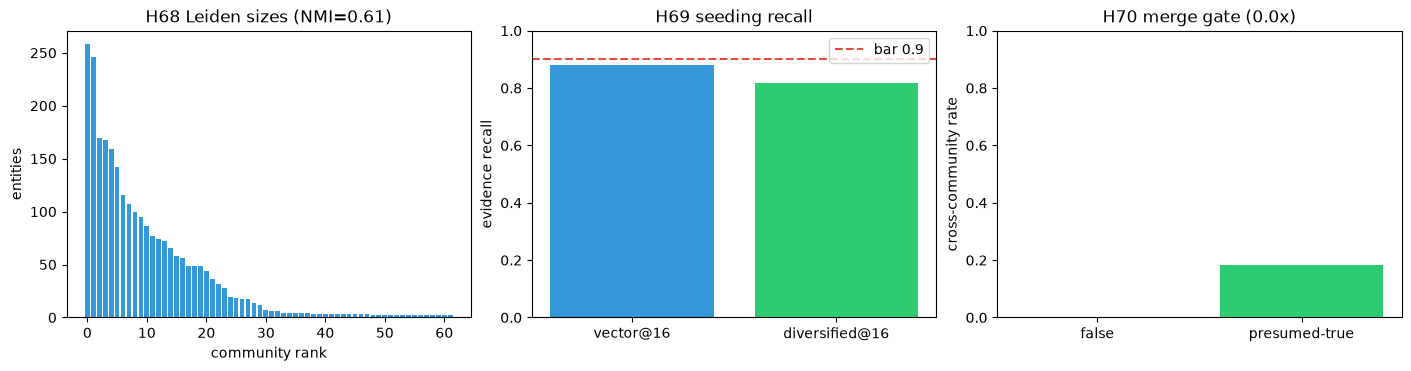

saved ../reports/communities-r09-20260707-090555.json

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), constrained_layout=True)
# H68 community sizes
sizes = sorted(Counter(community.values()).values(), reverse=True)
axes[0].bar(range(len(sizes)), sizes, color="#3498DB")
axes[0].set(xlabel="community rank", ylabel="entities", title=f"H68 Leiden sizes (NMI={nmi:.2f})")
# H69 recall
axes[1].bar(["vector@16", "diversified@16"], [base_recall, div_recall],
            color=["#3498DB", "#2ECC71"])
axes[1].axhline(BAR_H69_DIVERSE, color="#E74C3C", ls="--", label=f"bar {BAR_H69_DIVERSE}")
axes[1].set(ylabel="evidence recall", title="H69 seeding recall", ylim=(0, 1)); axes[1].legend()
# H70 rates
axes[2].bar(["false", "presumed-true"], [false_rate, true_rate], color=["#E74C3C", "#2ECC71"])
axes[2].set(ylabel="cross-community rate", title=f"H70 merge gate ({ratio:.1f}x)", ylim=(0, 1))
plt.show()

stamp = datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%d-%H%M%S")
out = Path("../reports") / f"communities-r09-{stamp}.json"
out.write_text(json.dumps({
    "h68": {"nmi": nmi, "homogeneity": homog, "mean_purity": mean_purity,
            "n_communities": len(comm_docs), "n_documents": len(set(lab_doc)),
            "verdict": h68_verdict},
    "h69": {"base_recall": base_recall, "div_recall": div_recall, "bar": BAR_H69_DIVERSE,
            "conc_low_recall": rl_low, "conc_high_recall": rl_high, "rows": rows,
            "verdict": h69_verdict},
    "h70": {"false_total": false_total, "false_cross": false_cross, "false_rate": false_rate,
            "true_total": true_total, "true_cross": true_cross, "true_rate": true_rate,
            "ratio": ratio if ratio != float("inf") else None, "verdict": h70_verdict,
            "false_detail": false_detail},
}, indent=2, default=str))
rprint("saved", str(out))